In [ ]:
!pip install kaggle

In [ ]:
from google.colab import files
files.upload()


Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"saisaket2004","key":"cedbfbf069383480ff72ebd1bec210c2"}'}

In [ ]:
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json


In [ ]:
!kaggle datasets download -d mexwell/stress-detection-from-social-media-articles
!unzip stress-detection-from-social-media-articles.zip

Dataset URL: https://www.kaggle.com/datasets/mexwell/stress-detection-from-social-media-articles
License(s): apache-2.0
100% 2.28M/2.28M [00:00<00:00, 45.2MB/s]

Archive:  stress-detection-from-social-media-articles.zip
  inflating: Reddit_Combi.csv        
  inflating: Reddit_Title.csv        
  inflating: Twitter_ Non-Advert-Tabelle 1.csv  
  inflating: Twitter_Full.csv        


In [ ]:
import pandas as pd
import numpy as np

df_reddit_combi = pd.read_csv(
    "Reddit_Combi.csv",
    sep=";",
    engine="python",
    on_bad_lines="skip"
)

df_reddit_combi = df_reddit_combi[['Body_Title', 'label']]
df_reddit_combi.rename(columns={'Body_Title': 'text'}, inplace=True)
df_reddit_combi.dropna(inplace=True)

In [ ]:
df_reddit_title = pd.read_csv(
    "Reddit_Title.csv",
    sep=";",
    engine="python",
    on_bad_lines="skip"
)

print(df_reddit_title.columns.tolist())

['title', 'label', 'Unnamed: 2', 'Unnamed: 3', 'Unnamed: 4']


In [ ]:
df_reddit_title = df_reddit_title[['title', 'label']]
df_reddit_title.rename(columns={'title': 'text'}, inplace=True)
df_reddit_title.dropna(inplace=True)

df_reddit_title.head()

,text,label
0,My aunt and uncle scoring their first gig as p...,0
1,How do I stop stressing about work when I'm at...,1
2,Meeting a fellow suicidal student in middle sc...,1
3,My brain feels literally numb. Is this depress...,1
4,A mother's reaction after seeing her son has p...,0


In [ ]:
df_twitter = pd.read_csv(
    "Twitter_Full.csv",
    sep=";",
    engine="python",
    on_bad_lines="skip"
)

print(df_twitter.columns.tolist())


['text', 'hashtags', 'labels', 'Unnamed: 3', 'Unnamed: 4']


In [ ]:
df_twitter = df_twitter[['text', 'labels']]
df_twitter.rename(columns={'labels': 'label'}, inplace=True)
df_twitter.dropna(inplace=True)

df_twitter.head()


,text,label
0,Being s mom is cleaning 24/7 the same shit ove...,1
1,And now we have been given the walkthru book b...,0
2,Wishing YOU Peace Joy & Love! JoyTrain MentalH...,0
3,speak-no-evil monkey Can I Be Honest With You...,1
4,Psy Do u hv any regrets? Me No Psy Are you hap...,0


In [ ]:
df = pd.concat(
    [df_reddit_combi, df_reddit_title, df_twitter],
    ignore_index=True
)

df.shape


(17576, 2)

In [ ]:
df['label'].value_counts()


,count
label,
1,10022
0,7554


In [ ]:
import numpy as np

def map_stress(label):
    if int(label) == 0:
        return "Low"
    else:
        return np.random.choice(["Medium", "High"], p=[0.6, 0.4])

df['stress_level'] = df['label'].apply(map_stress)

df['stress_level'].value_counts()


,count
stress_level,
Low,7554
Medium,5956
High,4066


In [ ]:
def generate_lifestyle(stress):
    if stress == "Low":
        return (
            np.random.uniform(7, 9),
            np.random.uniform(3, 6),
            np.random.uniform(1, 4),
            1
        )
    elif stress == "Medium":
        return (
            np.random.uniform(5, 7),
            np.random.uniform(6, 9),
            np.random.uniform(3, 6),
            np.random.choice([0, 1])
        )
    else:
        return (
            np.random.uniform(3, 5),
            np.random.uniform(9, 12),
            np.random.uniform(6, 10),
            0
        )

df[['sleep_hours',
    'work_study_hours',
    'screen_time_hours',
    'physical_activity']] = df['stress_level'].apply(
        lambda x: pd.Series(generate_lifestyle(x))
)

In [ ]:
def add_noise(df, noise_level=0.15):
    df_noisy = df.copy()

    numeric_cols = [
        'sleep_hours',
        'work_study_hours',
        'screen_time_hours'
    ]

    for col in numeric_cols:
        noise = np.random.normal(
            loc=0,
            scale=noise_level * df_noisy[col].std(),
            size=len(df_noisy)
        )
        df_noisy[col] = df_noisy[col] + noise


    flip_idx = df_noisy.sample(frac=0.05, random_state=42).index
    df_noisy.loc[flip_idx, 'physical_activity'] = (
        1 - df_noisy.loc[flip_idx, 'physical_activity']
    )

    return df_noisy


In [ ]:
df_noisy = add_noise(df, noise_level=0.15)

print("df_noisy created successfully!")
print(df_noisy.head())

df_noisy created successfully!
                                                text  label stress_level  \
0  Envy to other is swallowing me Im from develop...      1       Medium   
1  Nothin outta the ordinary. Paradise. Job stres...      1       Medium   
2  Almost 49 and the chasm of emptiness has never...      1         High   
3  I’m happy again After my closest friend left m...      0          Low   
4  Is it possible to recover from such a traumati...      1       Medium   

   sleep_hours  work_study_hours  screen_time_hours  physical_activity  
0     6.109152          5.975248           5.310636                1.0  
1     5.945013          9.076204           3.855934                0.0  
2     3.409116         10.704823          10.108758                0.0  
3     7.040311          3.119004           2.997719                0.0  
4     5.187473          8.154288           5.681210                0.0  


In [ ]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense, Embedding, LSTM, Concatenate, Dropout, GlobalMaxPooling1D
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
import pickle

X_text = df_noisy['text'].astype(str).values
X_num = df_noisy[['sleep_hours', 'work_study_hours', 'screen_time_hours', 'physical_activity']].values
y = df_noisy['stress_level'].values

label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)
y_categorical = tf.keras.utils.to_categorical(y_encoded)

X_text_train, X_text_test, X_num_train, X_num_test, y_train, y_test = train_test_split(
    X_text, X_num, y_categorical, test_size=0.2, random_state=42, stratify=y_encoded
)

MAX_WORDS = 10000
MAX_LEN = 100
EMBEDDING_DIM = 50

tokenizer = Tokenizer(num_words=MAX_WORDS, oov_token="<OOV>")
tokenizer.fit_on_texts(X_text_train)

X_text_train_seq = tokenizer.texts_to_sequences(X_text_train)
X_text_test_seq = tokenizer.texts_to_sequences(X_text_test)

X_text_train_pad = pad_sequences(X_text_train_seq, maxlen=MAX_LEN, padding='post', truncating='post')
X_text_test_pad = pad_sequences(X_text_test_seq, maxlen=MAX_LEN, padding='post', truncating='post')

scaler = StandardScaler()
X_num_train_scaled = scaler.fit_transform(X_num_train)
X_num_test_scaled = scaler.transform(X_num_test)

input_text = Input(shape=(MAX_LEN,), name="text_input")
embedding = Embedding(input_dim=MAX_WORDS, output_dim=EMBEDDING_DIM)(input_text)
lstm_layer = LSTM(64, return_sequences=False)(embedding)

input_num = Input(shape=(4,), name="num_input")
dense_num = Dense(32, activation='relu')(input_num)

concat = Concatenate()([lstm_layer, dense_num])

dense_1 = Dense(64, activation='relu')(concat)
dropout = Dropout(0.3)(dense_1)
output = Dense(3, activation='softmax')(dropout)

model = Model(inputs=[input_text, input_num], outputs=output)

model.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics=['accuracy'])

model.summary()

history = model.fit(
    [X_text_train_pad, X_num_train_scaled], y_train,
    validation_data=([X_text_test_pad, X_num_test_scaled], y_test),
    epochs=10,
    batch_size=32,
    verbose=1
)

loss, accuracy = model.evaluate([X_text_test_pad, X_num_test_scaled], y_test)
print(f"Test Accuracy: {accuracy*100:.2f}%")

model.save('stress_hybrid_model.h5')

with open('tokenizer.pickle', 'wb') as handle:
    pickle.dump(tokenizer, handle, protocol=pickle.HIGHEST_PROTOCOL)

with open('scaler.pickle', 'wb') as handle:
    pickle.dump(scaler, handle, protocol=pickle.HIGHEST_PROTOCOL)

with open('label_encoder.pickle', 'wb') as handle:
    pickle.dump(label_encoder, handle, protocol=pickle.HIGHEST_PROTOCOL)


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ text_input          │ (None, 100)       │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding           │ (None, 100, 50)   │    500,000 │ text_input[0][0]  │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ num_input           │ (None, 4)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm (LSTM)         │ (None, 64)        │     29,440 │ embedding[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 32)        │        160 │ num_input[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 96)        │          0 │ lstm[0][0],       │
│ (Concatenate)       │                   │            │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 64)        │      6,208 │ concatenate[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 64)        │          0 │ dense_1[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 3)         │        195 │ dropout[0][0]     │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 536,003 (2.04 MB)

 Trainable params: 536,003 (2.04 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
440/440 ━━━━━━━━━━━━━━━━━━━━ 30s 61ms/step - accuracy: 0.9458 - loss: 0.1640 - val_accuracy: 0.9960 - val_loss: 0.0170
Epoch 2/10
440/440 ━━━━━━━━━━━━━━━━━━━━ 59s 102ms/step - accuracy: 0.9950 - loss: 0.0172 - val_accuracy: 0.9940 - val_loss: 0.0196
Epoch 3/10
440/440 ━━━━━━━━━━━━━━━━━━━━ 26s 58ms/step - accuracy: 0.9959 - loss: 0.0116 - val_accuracy: 0.9963 - val_loss: 0.0088
Epoch 4/10
440/440 ━━━━━━━━━━━━━━━━━━━━ 41s 57ms/step - accuracy: 0.9962 - loss: 0.0121 - val_accuracy: 0.9977 - val_loss: 0.0079
Epoch 5/10
440/440 ━━━━━━━━━━━━━━━━━━━━ 32s 74ms/step - accuracy: 0.9967 - loss: 0.0097 - val_accuracy: 0.9966 - val_loss: 0.0119
Epoch 6/10
440/440 ━━━━━━━━━━━━━━━━━━━━ 34s 59ms/step - accuracy: 0.9974 - loss: 0.0087 - val_accuracy: 0.9966 - val_loss: 0.0093
Epoch 7/10
440/440 ━━━━━━━━━━━━━━━━━━━━ 28s 63ms/step - accuracy: 0.9968 - loss: 0.0093 - val_accuracy: 0.9954 - val_loss: 0.0135
Epoch 8/10
440/440 ━━━━━━━━━━━━━━━━━━━━ 27s 61ms/step - accuracy: 0.9967 - loss: 0.0093 -

Test Accuracy: 99.35%
Model and processors saved successfully!


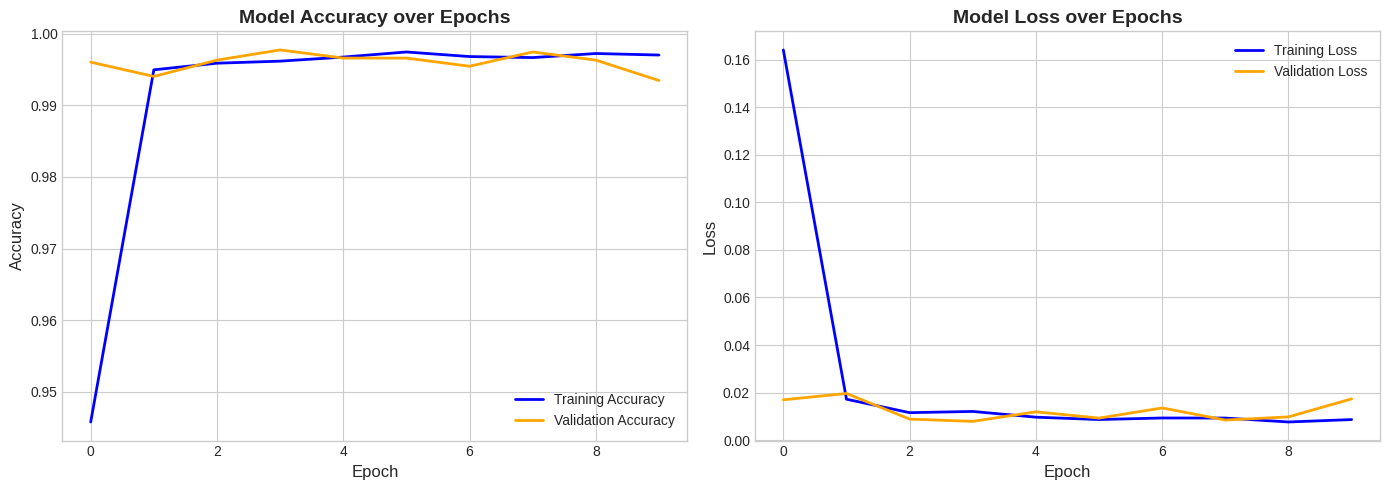

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
import matplotlib.pyplot as plt
plt.style.use('seaborn-v0_8-whitegrid')
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(history.history['accuracy'], label='Training Accuracy', color='blue', linewidth=2)
ax1.plot(history.history['val_accuracy'], label='Validation Accuracy', color='orange', linewidth=2)
ax1.set_title('Model Accuracy over Epochs', fontsize=14, fontweight='bold')
ax1.set_xlabel('Epoch', fontsize=12)
ax1.set_ylabel('Accuracy', fontsize=12)
ax1.legend(loc='lower right')

ax2.plot(history.history['loss'], label='Training Loss', color='blue', linewidth=2)
ax2.plot(history.history['val_loss'], label='Validation Loss', color='orange', linewidth=2)
ax2.set_title('Model Loss over Epochs', fontsize=14, fontweight='bold')
ax2.set_xlabel('Epoch', fontsize=12)
ax2.set_ylabel('Loss', fontsize=12)
ax2.legend(loc='upper right')

plt.tight_layout()
plt.savefig('learning_curves.png', dpi=300)
plt.show()

110/110 ━━━━━━━━━━━━━━━━━━━━ 2s 16ms/step


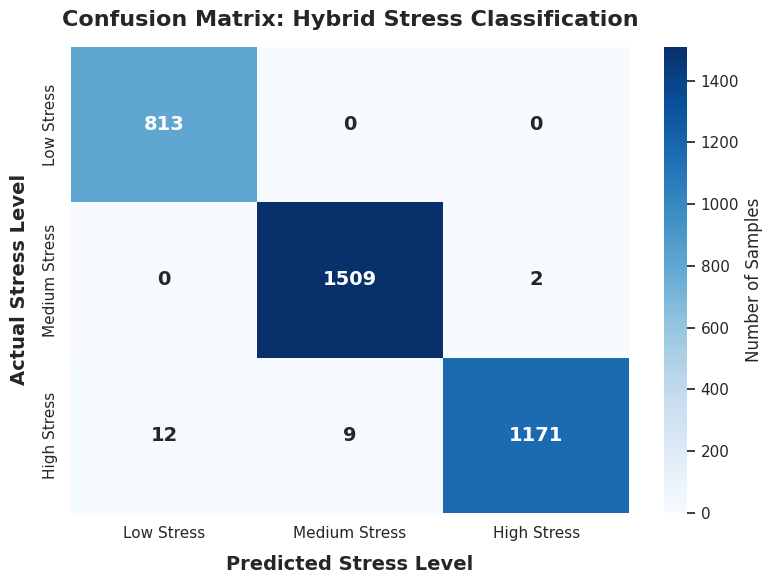

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

y_pred_prob = model.predict([X_text_test_pad, X_num_test_scaled])

y_pred = np.argmax(y_pred_prob, axis=1)
y_true = np.argmax(y_test, axis=1)

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(8, 6))
sns.set_theme(style="white")

ax = sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                 xticklabels=['Low Stress', 'Medium Stress', 'High Stress'],
                 yticklabels=['Low Stress', 'Medium Stress', 'High Stress'],
                 annot_kws={"size": 14, "weight": "bold"},
                 cbar_kws={'label': 'Number of Samples'})

plt.title('Confusion Matrix: Hybrid Stress Classification', fontsize=16, fontweight='bold', pad=15)
plt.xlabel('Predicted Stress Level', fontsize=14, fontweight='bold', labelpad=10)
plt.ylabel('Actual Stress Level', fontsize=14, fontweight='bold', labelpad=10)

plt.tight_layout()

plt.savefig('confusion_matrix.png', dpi=300)
plt.show()